# Notebook for PSF denoising with a PSF generator
## Application to test PSF

In [ ]:
import torch
import os
from os import listdir
from os.path import isfile, join
import sys
from time import time
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import scipy
import scipy.optimize

grad = torch.autograd.grad

In [ ]:
sys.path.insert(1, "../training")
from wgan_gradient_penalty import *

## Log-equalizations

In [ ]:
# Log
def logeq2(Im):
    return np.log(10000*Im+1)/np.log(10001)+0.3
def logeq2_torch(Im):
    return torch.log(10000*Im+1)/np.log(10001)+0.3
def delogeq2(Im):
    return (10001**(Im-0.3)-1)/10000
def logeq(Im):
    return np.log(1000*Im+1)/np.log(1001)

# Log for visualization
def normminmax(Im):
    return (Im - np.min(Im))/(np.max(Im) - np.min(Im))
def viseq(Im):
    return logeq(normminmax(Im))



## Getting the PSF to denoise

In [ ]:
eq = "white"

In [ ]:
# Name of the PSF to denoise
path_datas = "../../data/sets/K12_2017_2019/"+eq+"/test/"
L_imgs = os.listdir(path_datas)
to_test = np.random.choice(L_imgs)

img_to_find = plt.imread(path_datas+to_test)[:,:,0]
print(to_test)
plt.imshow(img_to_find)
plt.show()

## Generator initialization

In [ ]:
ngpu=1
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
nc = 1
ndf = 128//4
n_dim=128

nz=20
training_s = "1719"
mode_eq = "log"
year = "2025"

white_gen = (mode_eq == "white")

In [ ]:
def MSE(A,B):
    return np.sum(np.nan_to_num(A-B)**2)/np.sum((1-np.isnan(A-B)))

In [ ]:
racine = "../../"
path_models_W = racine + "models/"

name_model_W = "generatorK12_"+year+"_train"+training_s+"_nlat"+str(nz)+"_"+mode_eq+".pkl"


path_MEAN_STD = "../data/statistics/"

In [ ]:
if white_gen:
    
    if training_s =="1719":
        suffix = "_k12"
    else:
        suffix = "_h23"
        
    MEAN = np.load(path_MEAN_STD+"MEAN_"+training_s+suffix+".npy")
    STD = np.load(path_MEAN_STD+"STD_"+training_s+suffix+".npy")
    
    MEAN_cuda= torch.Tensor(MEAN).to(device)
    STD_cuda= torch.Tensor(STD).to(device)
    
    bound_mini = -3.5
    bound_maxi = 9
    
    def unwhite(Im):
        return (Im * (bound_maxi - bound_mini) + bound_mini)*STD + MEAN
    def unwhite_cuda(Im):
        return (Im * (bound_maxi - bound_mini) + bound_mini)*STD_cuda + MEAN_cuda
    
    def whitening(Im): 
        return (Im-MEAN)/STD
    def whitening_complete(Im): 
        return (whitening(Im)-bound_mini)/(bound_maxi-bound_mini)
    def whitening_cuda(Im): 
        return (Im-MEAN_cuda)/STD_cuda
    def whitening_complete_cuda(Im):
        return (whitening_cuda(Im)-bound_mini)/(bound_maxi-bound_mini)

In [ ]:
if white_gen:
    eq = whitening_complete
    eq_torch = whitening_complete_cuda
    uneq = unwhite
    uneq_torch = unwhite_cuda
else:
    eq = logeq2
    eq_torch = logeq2_torch
    uneq = delogeq2
    uneq_torch = delogeq2

In [ ]:
wgan = WGAN_GP(nb_channels=1, cud=False, n_latent=nz, eq=eq_torch, uneq=uneq_torch, white=white_gen)
wgan.load_model_G(path_models_W + name_model_W)
best_gen = wgan.G.to(device)
best_gen = best_gen.eval()

In [ ]:
def generateur_GAN(params_GAN):
    if type(params_GAN) == list:
        v_latent = torch.reshape(torch.tensor(params_GAN, device=device), (1,nz,1,1))
    elif type(params_GAN) == np.ndarray:
        v_latent = torch.reshape(torch.tensor(params_GAN.astype(np.float32), device=device), (1,nz,1,1))
    elif type(params_GAN) == torch.Tensor:
        v_latent = torch.reshape(torch.tensor(params_GAN, device=device), (1,nz,1,1))
    else:    
        v_latent = torch.reshape(torch.tensor([val for val in params_GAN.values()], device=device), (1,nz,1,1))
    im = best_gen(v_latent)[0].detach()[0,:,:]
    #im = np.array((0.5 + im /2).cpu())
    im = np.array(im.cpu())
    return im
v_latent_init = torch.randn(64,nz,1,1, device=device)
def generateur_GAN_vect(params_GAN):
    v_latent = torch.reshape(torch.tensor(params_GAN, device=device), (1,nz,1,1)).float()
    
    im = best_gen(v_latent)[0].detach()[0,:,:]
    #im = np.array((0.5 + im /2).cpu())
    im = np.array(im.cpu())
    return im

In [ ]:
def complete_generator(z, logvis=False):
    if logvis:
        return viseq(uneq(generateur_GAN(z)))
    else:
        return uneq(generateur_GAN(z))

# Denoising

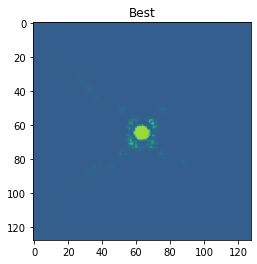


 0.002083135535940528 [  5.91009258   2.39847031   2.56560446  13.40911388  -9.39796162
   9.19013648  12.95917235 -11.69207561  -5.32158826  -7.80925815
   2.8631467  -13.84152065 -10.42873589   5.53451676  -5.45790744
   2.53506487   6.99897357  -7.47852007   7.06889213  -3.56511579]


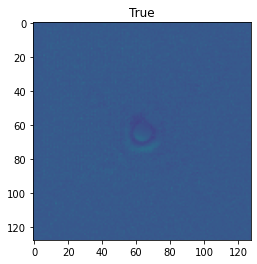

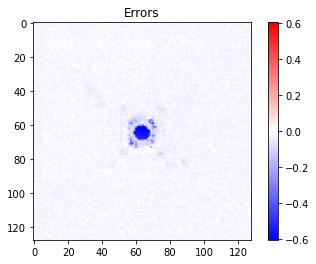

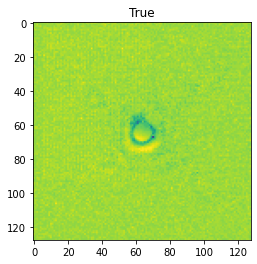

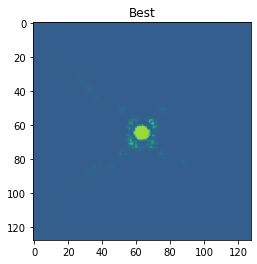


 0.002083142753690481 [  5.91009258   2.39847031   2.56560446  13.40911388  -9.39796162
   9.19013648  12.95917235 -11.69207561  -5.32158826  -7.80925815
   2.8631467  -13.84152065 -10.42873589   5.53451676  -5.45790744
   2.53506487   6.99897357  -7.47852007   7.06889213  -3.56511579]


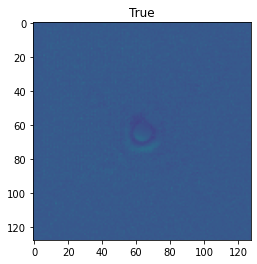

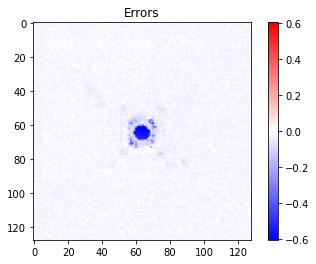

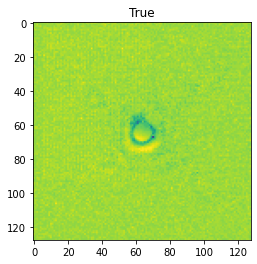

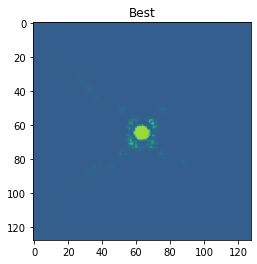


 0.002083143452182412 [  5.91009258   2.39847031   2.56560446  13.40911388  -9.39796162
   9.19013648  12.95917235 -11.69207561  -5.32158826  -7.80925815
   2.8631467  -13.84152065 -10.42873589   5.53451676  -5.45790744
   2.53506487   6.99897357  -7.47852007   7.06889213  -3.56511579]


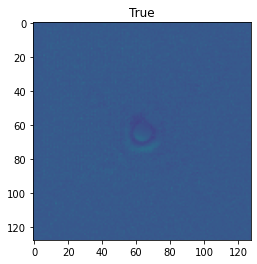

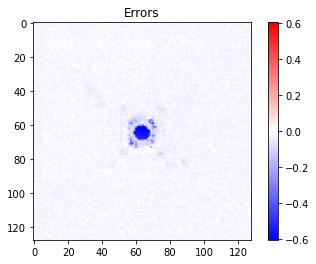

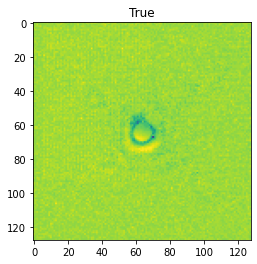

In [53]:
lamb=0.002 # Regularization on z
#lamb=0.000

# Define function to optimize
def func_to_opti1(par):
    im_test = generateur_GAN(par)
    return np.sum(np.nan_to_num(img_to_find - im_test)**2) + lamb*np.sum(par**2)

img_to_find_tensor = torch.Tensor(img_to_find).to(device)

def deriv_func(par): #Derivatives
    par_tensor = torch.Tensor(par).to(device)
    par_tensor.requires_grad=True
    res = torch.sum(torch.nan_to_num((best_gen(torch.reshape(par_tensor, (1,nz,1,1))) - img_to_find_tensor))**2)
    return np.array(grad(outputs=res, inputs=par_tensor)[0].detach().cpu()) + 2*lamb*par

best_gen.to(device)

best_MSE = 1000000000000000000
best_z = None

for i in range(10): # We try from 10 different starting points

    z = np.random.randn(nz) #Starting point

    L_suivi = [z] # If we want to follow the evolution

    def func_callback(xk):
        L_suivi.append(xk)

    # Minimization with BFGS
    res = scipy.optimize.minimize(func_to_opti1, z, method="BFGS", jac=deriv_func, callback=func_callback)

    # Compute MSE without the regularization
    if white_gen:
        new_MSE = MSE(logeq2(uneq(img_to_find)), logeq2(uneq(generateur_GAN_vect(res.x))))
    else:
        new_MSE = MSE(img_to_find, generateur_GAN_vect(res.x))

    # Keep the best (for the MSE criterium) z
    if new_MSE < best_MSE:
        best_MSE = new_MSE
        best_z = res.x

    # Show results
    z1 = best_z
    plt.imshow(generateur_GAN_vect(z1),vmin=0,vmax=1)
    plt.title("Best")
    plt.show()
    print("\n",new_MSE, z1)
    
    # Contrast between 0 and 1
    plt.imshow(img_to_find, vmin=0, vmax=1)
    plt.title("True")
    plt.show()

    # Show errors
    vminimaxi = np.max(abs(img_to_find - generateur_GAN_vect(z1)))
    plt.imshow((img_to_find - generateur_GAN_vect(z1)), cmap="bwr", vmin=-vminimaxi, vmax=vminimaxi)
    plt.title("Errors")
    plt.colorbar()
    plt.show()
    if white_gen:
        plt.imshow(viseq(uneq(img_to_find)), vmin=0, vmax=1)
    else:
        plt.imshow(viseq(uneq(img_to_find)), vmin=0, vmax=1)
    plt.title("True")
    plt.show()
